<a href="https://colab.research.google.com/github/muthuijack/ckdjack/blob/main/chronic_kidney_disease_project_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. import necessary libraries**

In [23]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical # Added for one-hot encoding

import joblib

# **2.load dataset**

In [24]:
import kagglehub
import os
print("🚀 Downloading dataset...")
path = kagglehub.dataset_download("aryanhirlekar/ckdchronic-kidney-disease-dataset-with-stages")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, csv_files[0]))

🚀 Downloading dataset...
Using Colab cache for faster access to the 'ckdchronic-kidney-disease-dataset-with-stages' dataset.


# **4. merge the two dataset**

In [25]:
df.shape

(4000, 23)

In [26]:
print (len(df.isnull().sum()))

23


In [27]:
print(df.head
      )

<bound method NDFrame.head of       serum_creatinine         gfr         bun  serum_calcium  ana  \
0             0.683683   32.946784    7.553739      10.039896    0   
1             3.809044   32.685035  141.347494       8.330543    1   
2             1.143827    2.079805   15.979104       9.419229    0   
3             4.804657  109.871407   53.307333       7.556631    1   
4             4.920235   42.214590  134.182157       7.289379    1   
...                ...         ...         ...            ...  ...   
3995          0.746929   55.157951   18.729510       8.660809    0   
3996          1.033439   87.580624    8.620124       8.895918    0   
3997          0.816066   76.076867   18.792486       9.858060    0   
3998          1.990560  101.914530  101.429299       8.096577    1   
3999          3.781494  115.228982   93.999278       5.289043    1   

           c3_c4  hematuria  oxalate_levels  urine_ph  blood_pressure  ...  \
0     138.204989          0        2.878164  7.8643

# **5. split the feature target column**

In [83]:
# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# Filter out rows where ckd_stage is not between 1 and 5 (inclusive)
# This removes any 0s or other anomalous values that would become -1 after 0-indexing
df = df[df['ckd_stage'].between(1, 5)]

# Add a print statement to confirm the new df shape after filtering
print(f"Shape of df after filtering: {df.shape}")

# Assign 'ckd_stage' as the new target column
X = df.drop(columns=["ckd_pred", "ckd_stage"])
y = df["ckd_stage"]

# Convert ckd_stage to be 0-indexed for multi-class classification
y = y - 1

# Add a print statement to confirm the new y distribution
print("New distribution of y after filtering and 0-indexing:")
print(y.value_counts().sort_index())

Shape of df after filtering: (3875, 23)
New distribution of y after filtering and 0-indexing:
ckd_stage
0     545
1    1004
2     866
3     794
4     666
Name: count, dtype: int64


In [44]:
print("Distribution of ckd_stage in training data:")
print(pd.Series(y_train).value_counts().sort_index())

Distribution of ckd_stage in training data:
ckd_stage
-1    100
 0    436
 1    803
 2    693
 3    635
 4    533
Name: count, dtype: int64


# **6. encode categorical columns**

In [91]:
cat_cols = X.select_dtypes(include="object").columns
print(f"Categorical columns identified before encoding: {list(cat_cols)}")

for col in cat_cols:
    # Ensure the column is treated as string for LabelEncoder
    # Then encode and assign back to the DataFrame
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# After LabelEncoder, explicitly ensure all columns are numeric
# This catches any columns not initially identified as 'object' but containing mixed types or strings
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce') # Convert to numeric, coercing errors to NaN

# Verify no object columns remain
remaining_cat_cols = X.select_dtypes(include="object").columns
if not remaining_cat_cols.empty:
    print(f"ERROR: Unencoded categorical columns still exist after LabelEncoder and numeric coercion: {list(remaining_cat_cols)}")
else:
    print("All categorical columns successfully encoded to numerical type.")
print(f"X dtypes after LabelEncoder and final numeric coercion:\n{X.dtypes}")

Categorical columns identified before encoding: ['physical_activity', 'diet', 'smoking', 'alcohol', 'painkiller_usage', 'family_history', 'weight_changes', 'stress_level']
All categorical columns successfully encoded to numerical type.
X dtypes after LabelEncoder and final numeric coercion:
serum_creatinine     float64
gfr                  float64
bun                  float64
serum_calcium        float64
ana                    int64
c3_c4                float64
hematuria              int64
oxalate_levels       float64
urine_ph             float64
blood_pressure       float64
physical_activity      int64
diet                   int64
water_intake         float64
smoking                int64
alcohol                int64
painkiller_usage       int64
family_history         int64
weight_changes         int64
stress_level           int64
months                 int64
cluster                int64
dtype: object


# **6. handle missing values**

In [30]:
df.isnull().sum()


,0
serum_creatinine,0
gfr,0
bun,0
serum_calcium,0
ana,0
c3_c4,0
hematuria,0
oxalate_levels,0
urine_ph,0
blood_pressure,0


In [92]:
#impute for small data
imputer = SimpleImputer(strategy="mean")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Ensure X is entirely numeric before proceeding to splitting and scaling
# This should catch any stray non-numeric values that might have been missed
# by LabelEncoder or if imputation returned non-numeric types unexpectedly.
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Re-impute any NaNs that might have been introduced by pd.to_numeric(errors='coerce')
# If a column was purely string that couldn't be encoded, this will turn it to NaN and impute.
if X.isnull().any().any():
    print("WARNING: NaNs found after forcing numeric conversion. Re-imputing remaining NaNs.")
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns) # Use the same imputer

# The masking operation 'mask = y.notna(); X = X.loc[mask]; y = y.loc[mask]' has been removed.
# This is because y is already confirmed to have no NaNs from cell 4f8MvbI3vjxL,
# and this step was causing an IndexingError due to index misalignment after X's transformation.

# Add a debug print for X.dtypes here to confirm
print(f"X dtypes after imputation and final numeric coercion:\n{X.dtypes}")

X dtypes after imputation and final numeric coercion:
serum_creatinine     float64
gfr                  float64
bun                  float64
serum_calcium        float64
ana                  float64
c3_c4                float64
hematuria            float64
oxalate_levels       float64
urine_ph             float64
blood_pressure       float64
physical_activity    float64
diet                 float64
water_intake         float64
smoking              float64
alcohol              float64
painkiller_usage     float64
family_history       float64
weight_changes       float64
stress_level         float64
months               float64
cluster              float64
dtype: object


In [32]:
df.isnull().sum()

,0
serum_creatinine,0
gfr,0
bun,0
serum_calcium,0
ana,0
c3_c4,0
hematuria,0
oxalate_levels,0
urine_ph,0
blood_pressure,0


## **7. split the data set**

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [94]:
scaler = StandardScaler()

print(f"X_train dtypes before scaling:\n{X_train.dtypes}") # Add this debug print

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train dtypes before scaling:
serum_creatinine     float64
gfr                  float64
bun                  float64
serum_calcium        float64
ana                  float64
c3_c4                float64
hematuria            float64
oxalate_levels       float64
urine_ph             float64
blood_pressure       float64
physical_activity    float64
diet                 float64
water_intake         float64
smoking              float64
alcohol              float64
painkiller_usage     float64
family_history       float64
weight_changes       float64
stress_level         float64
months               float64
cluster              float64
dtype: object


In [35]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (3200, 21)
Shape of X_test: (800, 21)
Shape of y_train: (3200,)
Shape of y_test: (800,)


# **9. load the model**

In [95]:
num_classes = len(y.unique())

model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(num_classes, activation="softmax") # Output layer for multi-class classification
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy", # Changed to categorical_crossentropy for one-hot encoded labels
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **10. train the model[link text](https://)**

In [96]:
# Convert y_train and y_test to one-hot encoded format
y_train_ohe = to_categorical(y_train, num_classes=num_classes)
y_test_ohe = to_categorical(y_test, num_classes=num_classes)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train_ohe, # Use one-hot encoded labels for training
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.3435 - loss: 1.4644 - val_accuracy: 0.4855 - val_loss: 1.1818
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5040 - loss: 1.0851 - val_accuracy: 0.6710 - val_loss: 0.8549
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6254 - loss: 0.8337 - val_accuracy: 0.7968 - val_loss: 0.6483
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7109 - loss: 0.6703 - val_accuracy: 0.8242 - val_loss: 0.5272
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7319 - loss: 0.5963 - val_accuracy: 0.8065 - val_loss: 0.4685
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7794 - loss: 0.5125 - val_accuracy: 0.8629 - val_loss: 0.4019
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8028 - loss: 0.4676 - val_accuracy: 0.8871 - val_loss: 0.3558
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8097 - loss: 0.4302 - val_accuracy: 0.8806 - val_loss

In [38]:
print("Distribution of ckd_stage in training data:")
print(pd.Series(y_train).value_counts().sort_index())

Distribution of ckd_stage in training data:
ckd_stage
-1    100
 0    436
 1    803
 2    693
 3    635
 4    533
Name: count, dtype: int64


In [97]:
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


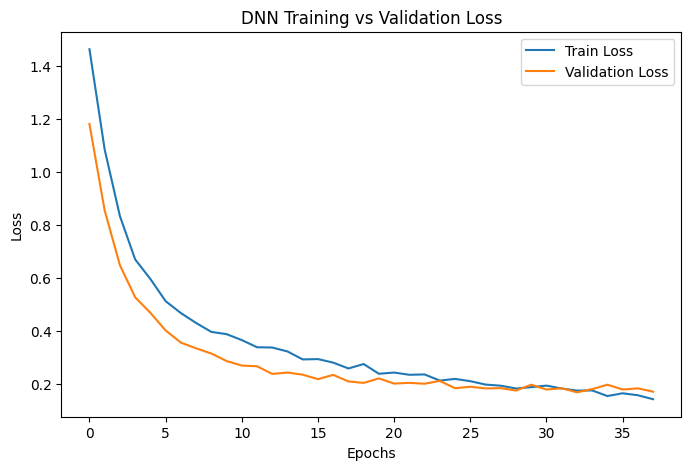

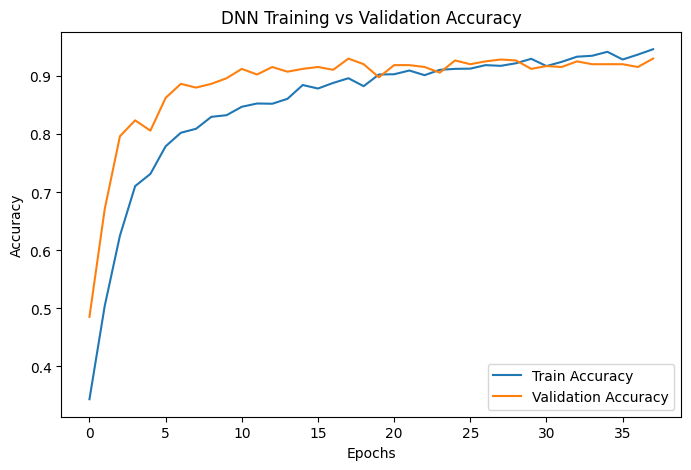

In [99]:
import matplotlib.pyplot as plt

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("DNN Training vs Validation Loss")
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("DNN Training vs Validation Accuracy")
plt.legend()
plt.show()

Unique values in y_test: [0 1 2 3 4]
Max value in y_test: 4
Unique values in y_pred: [0 1 2 3 4]
Max value in y_pred: 4
Number of classes (num_classes): 5


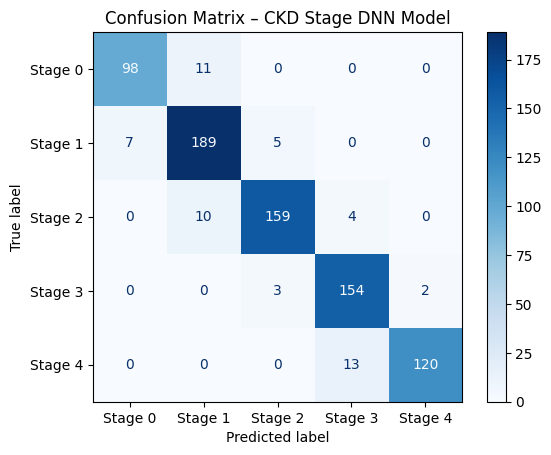

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np # Ensure np is imported if not already

# Debugging prints to verify class range
print(f"Unique values in y_test: {np.unique(y_test)}")
print(f"Max value in y_test: {y_test.max()}")
print(f"Unique values in y_pred: {np.unique(y_pred)}")
print(f"Max value in y_pred: {y_pred.max()}")
print(f"Number of classes (num_classes): {num_classes}")

# Explicitly set labels for confusion_matrix to ensure 5x5 matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(num_classes) # Force it to consider only classes 0 to num_classes-1
)

# Create display labels for the 5 stages (0-indexed)
stage_labels = [f"Stage {i}" for i in range(num_classes)]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=stage_labels
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix – CKD Stage DNN Model")
plt.show()

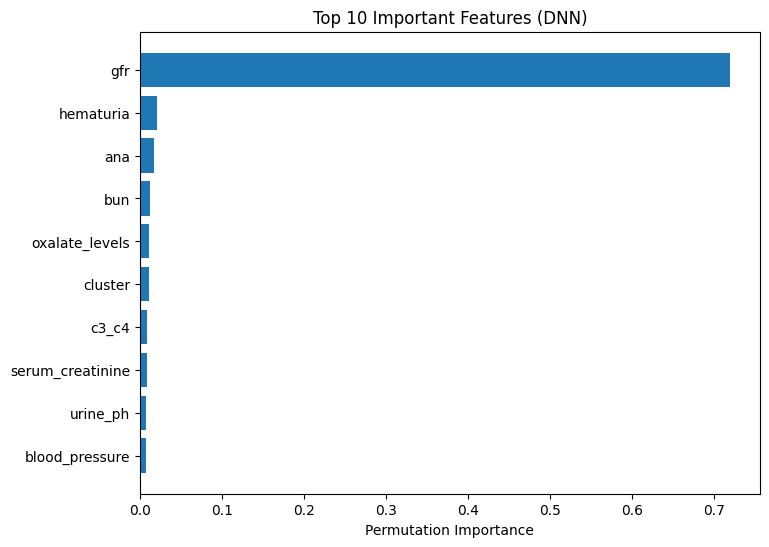

In [101]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score
import numpy as np # Ensure numpy is imported for argmax

# Define a custom scoring function that permutation_importance can use
def custom_accuracy_scorer(estimator, X, y_true):
    # Keras model.predict returns probabilities
    y_pred_proba = estimator.predict(X, verbose=0)
    # Convert probabilities to single class labels by taking the argmax
    y_pred = np.argmax(y_pred_proba, axis=1)
    return accuracy_score(y_true, y_pred)

# Pass this custom function directly as the scoring argument
r = permutation_importance(model, X_test, y_test, n_repeats=30, random_state=42, scoring=custom_accuracy_scorer)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': r.importances_mean
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(
    importance_df["feature"][:10],
    importance_df["importance"][:10]
)
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance")
plt.title("Top 10 Important Features (DNN)")
plt.show()

PermutationExplainer explainer: 101it [00:11,  1.68it/s]                         
/tmp/ipykernel_3495/3282952182.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:100], feature_names=X.columns)


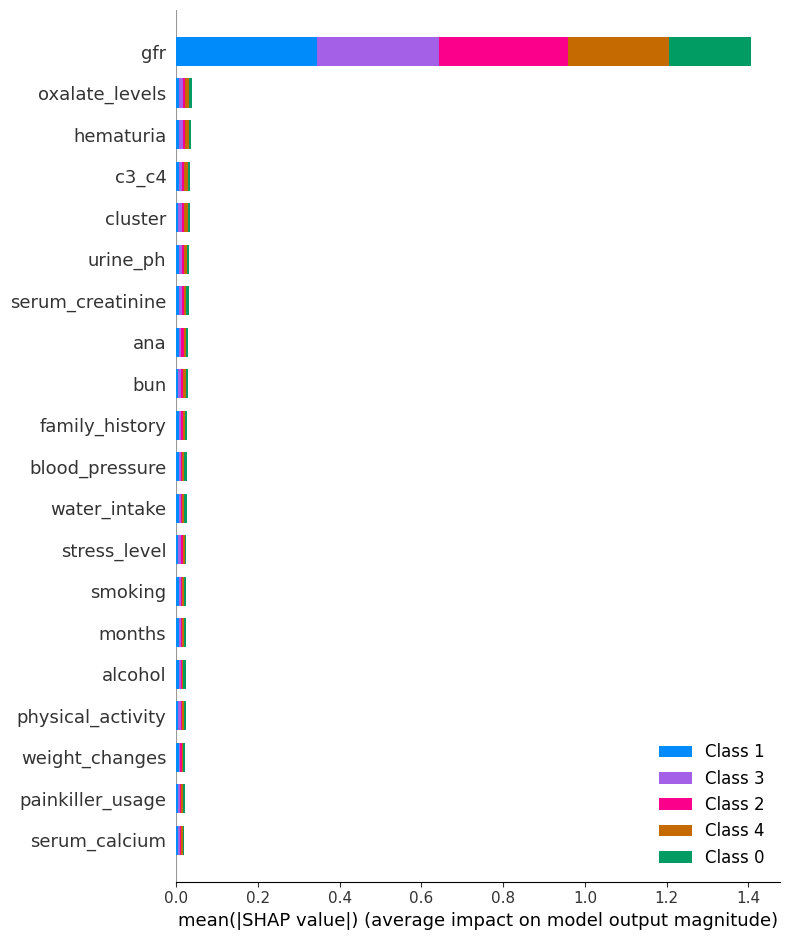

In [102]:
!pip install shap
import shap

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test[:100])

shap.summary_plot(shap_values, X_test[:100], feature_names=X.columns)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step
6532/6532 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
6532/6532 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
6532/6532 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
6532/6532 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
6532/6532 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
6532/6532 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6532/6532 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
6532/6532 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
6532/6532 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
6532/6532 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
6532/6532 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
6532/6532 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

/tmp/ipykernel_3495/1541717566.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy g

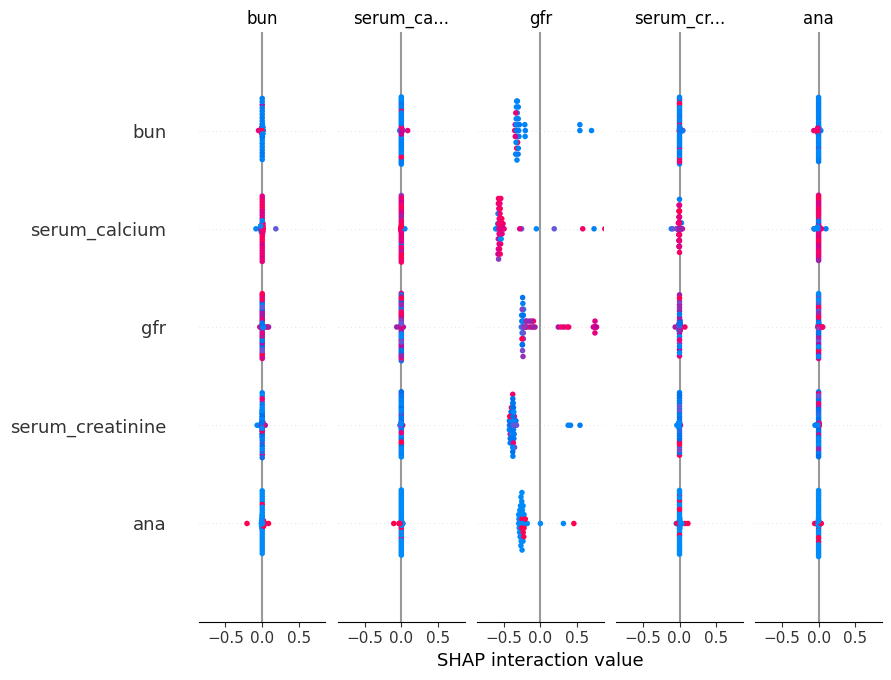

In [103]:
import shap

# Use small background set for speed
background = X_train[:100]

explainer = shap.KernelExplainer(
    model.predict,
    background
)

shap_values = explainer.shap_values(X_test[:50])
shap.summary_plot(
    shap_values,
    X_test[:50],
    feature_names=X.columns
)

# **model save**

In [105]:
model.save("ckd_stage_dnn_model.keras")
joblib.dump(scaler, "ckd_stage_scaler.pkl")
print("Model and scaler saved successfully!")

Model and scaler saved successfully!
